# Calidad del Aire CDMX 2024-2026

En este notebook se juntan los archivos de contaminantes de 2024, 2025 y 2026 para hacer un proceso ETL y un primer EDA.

Los datos están en la carpeta `DataBases` y corresponden a mediciones horarias por estación y contaminante.


## 1. Librerías y rutas


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:,.2f}'.format)

base_path = Path('DataBases')
files = [
    base_path / 'contaminantes_2024.csv',
    base_path / 'contaminantes_2025.csv',
    base_path / 'contaminantes_2026.csv',
]

files


[WindowsPath('DataBases/contaminantes_2024.csv'),
 WindowsPath('DataBases/contaminantes_2025.csv'),
 WindowsPath('DataBases/contaminantes_2026.csv')]

## 2. Extract

Los CSV tienen metadatos antes del encabezado. Por eso se busca la fila donde empiezan las columnas reales (`date`, `id_station`, `id_parameter`, `value` o `valor`, `unit`).


In [2]:
def find_header_row(path):
    with open(path, 'r', encoding='utf-8', errors='ignore') as file:
        for row_number, line in enumerate(file):
            if 'date' in line and 'id_station' in line and 'id_parameter' in line:
                return row_number
    raise ValueError(f'No se encontró encabezado en {path.name}')


def read_air_file(path):
    header_row = find_header_row(path)
    df = pd.read_csv(path, skiprows=header_row)
    df = df.rename(columns={'value': 'valor'})
    df.columns = df.columns.str.strip().str.lower()
    df['source_file'] = path.name
    return df

raw_frames = [read_air_file(path) for path in files]

for path, frame in zip(files, raw_frames):
    print(path.name, frame.shape)
    display(frame.head())


contaminantes_2024.csv (2430675, 6)


,date,id_station,id_parameter,valor,unit,source_file
0,2024-01-01 01:00:00,ACO,CO,NaN,15,contaminantes_2024.csv
1,2024-01-01 01:00:00,ACO,NO,NaN,1,contaminantes_2024.csv
2,2024-01-01 01:00:00,ACO,NO2,NaN,1,contaminantes_2024.csv
3,2024-01-01 01:00:00,ACO,NOX,NaN,1,contaminantes_2024.csv
4,2024-01-01 01:00:00,ACO,O3,NaN,1,contaminantes_2024.csv


contaminantes_2025.csv (2530182, 6)


,date,id_station,id_parameter,valor,unit,source_file
0,2025-01-01 00:00:00,ACO,O3,NaN,1,contaminantes_2025.csv
1,2025-01-01 00:00:00,ACO,SO2,NaN,1,contaminantes_2025.csv
2,2025-01-01 00:00:00,ACO,CO,NaN,15,contaminantes_2025.csv
3,2025-01-01 00:00:00,ACO,NO2,NaN,1,contaminantes_2025.csv
4,2025-01-01 00:00:00,ACO,NO,NaN,1,contaminantes_2025.csv


contaminantes_2026.csv (433296, 6)


,date,id_station,id_parameter,valor,unit,source_file
0,2026-01-01 00:00:00,ACO,CO,NaN,NaN,contaminantes_2026.csv
1,2026-01-01 00:00:00,ACO,NO,NaN,NaN,contaminantes_2026.csv
2,2026-01-01 00:00:00,ACO,NO2,NaN,NaN,contaminantes_2026.csv
3,2026-01-01 00:00:00,ACO,NOX,NaN,NaN,contaminantes_2026.csv
4,2026-01-01 00:00:00,ACO,O3,NaN,NaN,contaminantes_2026.csv


## 3. Transform

Se estandarizan nombres de columnas, fechas y tipos de datos. En 2024 hay fechas con hora y otras solo con día, así que se usa `format='mixed'` para conservar ambos formatos.


In [3]:
df = pd.concat(raw_frames, ignore_index=True)

text_columns = ['id_station', 'id_parameter', 'source_file']
for column in text_columns:
    df[column] = df[column].astype('string').str.strip()

df['date'] = pd.to_datetime(df['date'], errors='coerce', format='mixed')
df['valor'] = pd.to_numeric(df['valor'], errors='coerce')
df['unit'] = pd.to_numeric(df['unit'], errors='coerce')

df['year'] = df['date'].dt.year.astype('Int64')
df['month'] = df['date'].dt.month.astype('Int64')
df['day'] = df['date'].dt.day.astype('Int64')
df['hour'] = df['date'].dt.hour.astype('Int64')
df['date_only'] = df['date'].dt.date

print('Filas totales:', df.shape[0])
print('Columnas:', df.shape[1])
df.head()


Filas totales: 5394153
Columnas: 11


,date,id_station,id_parameter,valor,unit,source_file,year,month,day,hour,date_only
0,2024-01-01 01:00:00,ACO,CO,NaN,15.00,contaminantes_2024.csv,2024,1,1,1,2024-01-01
1,2024-01-01 01:00:00,ACO,NO,NaN,1.00,contaminantes_2024.csv,2024,1,1,1,2024-01-01
2,2024-01-01 01:00:00,ACO,NO2,NaN,1.00,contaminantes_2024.csv,2024,1,1,1,2024-01-01
3,2024-01-01 01:00:00,ACO,NOX,NaN,1.00,contaminantes_2024.csv,2024,1,1,1,2024-01-01
4,2024-01-01 01:00:00,ACO,O3,NaN,1.00,contaminantes_2024.csv,2024,1,1,1,2024-01-01


## 4. Revisión de calidad

Antes del análisis se revisan nulos, duplicados y rangos de fecha.


In [4]:
quality_summary = pd.DataFrame({
    'tipo_dato': df.dtypes.astype(str),
    'nulos': df.isna().sum(),
    'porcentaje_nulos': (df.isna().mean() * 100).round(2),
    'valores_unicos': df.nunique(dropna=True)
})

quality_summary


,tipo_dato,nulos,porcentaje_nulos,valores_unicos
date,datetime64[ns],0,0.00,18950
id_station,string,0,0.00,36
id_parameter,string,0,0.00,9
valor,float64,2357916,43.71,884
unit,float64,352512,6.54,3
source_file,string,0,0.00,3
year,Int64,0,0.00,3
month,Int64,0,0.00,12
day,Int64,0,0.00,31
hour,Int64,0,0.00,24


In [5]:
duplicated_rows = df.duplicated().sum()

date_summary = df.groupby('year').agg(
    fecha_minima=('date', 'min'),
    fecha_maxima=('date', 'max'),
    registros=('date', 'size'),
    estaciones=('id_station', 'nunique'),
    contaminantes=('id_parameter', 'nunique')
)

print('Filas duplicadas:', duplicated_rows)
date_summary


Filas duplicadas: 0


,fecha_minima,fecha_maxima,registros,estaciones,contaminantes
year,,,,,
2024,2024-01-01 01:00:00,2024-12-31 23:00:00,2430675,36,9
2025,2025-01-01 00:00:00,2025-12-31 23:00:00,2530182,34,9
2026,2026-01-01 00:00:00,2026-02-28 23:00:00,433296,34,9


## 5. Limpieza para análisis

Para calcular estadísticas se trabaja con registros que tengan fecha, estación, contaminante y valor medido. También se revisan duplicados reales por medición.


In [6]:
df_with_measurement = df.dropna(subset=['date', 'id_station', 'id_parameter', 'valor']).copy()
duplicates_in_clean = df_with_measurement.duplicated().sum()
df_clean = df_with_measurement.drop_duplicates().copy()

unit_by_parameter = (
    df_clean.dropna(subset=['unit'])
    .groupby('id_parameter')['unit']
    .agg(lambda values: values.mode().iloc[0])
)

df_clean['unit'] = df_clean['unit'].fillna(df_clean['id_parameter'].map(unit_by_parameter))

print('Registros originales:', len(df))
print('Registros con medición válida:', len(df_with_measurement))
print('Duplicados eliminados:', duplicates_in_clean)
print('Registros listos para EDA:', len(df_clean))
print('Registros eliminados por datos clave faltantes:', len(df) - len(df_with_measurement))

df_clean.head()


Registros originales: 5394153
Registros con medición válida: 3036237
Duplicados eliminados: 0
Registros listos para EDA: 3036237
Registros eliminados por datos clave faltantes: 2357916


,date,id_station,id_parameter,valor,unit,source_file,year,month,day,hour,date_only
7,2024-01-01 01:00:00,AJM,CO,0.23,15.00,contaminantes_2024.csv,2024,1,1,1,2024-01-01
8,2024-01-01 01:00:00,AJM,NO,0.00,1.00,contaminantes_2024.csv,2024,1,1,1,2024-01-01
9,2024-01-01 01:00:00,AJM,NO2,10.00,1.00,contaminantes_2024.csv,2024,1,1,1,2024-01-01
10,2024-01-01 01:00:00,AJM,NOX,10.00,1.00,contaminantes_2024.csv,2024,1,1,1,2024-01-01
11,2024-01-01 01:00:00,AJM,O3,43.00,1.00,contaminantes_2024.csv,2024,1,1,1,2024-01-01


## 6. Load

El dataframe final queda en `df_clean`. Si se necesita entregar una base transformada, se puede guardar como CSV.


In [7]:
output_path = base_path / 'contaminantes_2024_2026_limpio.csv'

# Descomenta esta línea si quieres guardar la base transformada.
# df_clean.to_csv(output_path, index=False)

output_path


WindowsPath('DataBases/contaminantes_2024_2026_limpio.csv')

## 7. EDA general

Primero se revisa el tamaño de la base limpia, años disponibles, estaciones y contaminantes.


In [8]:
eda_resume = pd.DataFrame({
    'metrica': [
        'registros_limpios',
        'fecha_minima',
        'fecha_maxima',
        'anios',
        'estaciones',
        'contaminantes'
    ],
    'valor': [
        len(df_clean),
        df_clean['date'].min(),
        df_clean['date'].max(),
        df_clean['year'].nunique(),
        df_clean['id_station'].nunique(),
        df_clean['id_parameter'].nunique()
    ]
})

eda_resume


,metrica,valor
0,registros_limpios,3036237
1,fecha_minima,2024-01-01 01:00:00
2,fecha_maxima,2026-02-28 23:00:00
3,anios,3
4,estaciones,33
5,contaminantes,9


In [9]:
parameter_counts = (
    df_clean['id_parameter']
    .value_counts()
    .rename_axis('contaminante')
    .reset_index(name='registros')
)

parameter_counts


,contaminante,registros
0,O3,475536
1,CO,408175
2,NO2,400657
3,SO2,400074
4,NO,351908
5,NOX,351602
6,PM10,273971
7,PM2.5,227104
8,PMCO,147210


## 8. Medidas de tendencia central

Se calculan media, mediana y moda de `valor`. Primero se obtiene una tabla general por contaminante y después una tabla por contaminante y año.


In [10]:
def first_mode(values):
    modes = values.mode(dropna=True)
    if modes.empty:
        return np.nan
    return modes.iloc[0]

central_tendency_by_parameter = (
    df_clean
    .groupby('id_parameter')['valor']
    .agg(
        registros='count',
        media='mean',
        mediana='median',
        moda=first_mode,
        minimo='min',
        maximo='max',
        desviacion_estandar='std'
    )
    .sort_values('media', ascending=False)
)

central_tendency_by_parameter.round(2)


,registros,media,mediana,moda,minimo,maximo,desviacion_estandar
id_parameter,,,,,,,
PM10,273971,41.82,36.00,26.00,0.00,652.00,27.92
NOX,351602,36.67,26.00,14.00,0.00,575.00,35.79
O3,475536,32.41,25.00,2.00,-1.00,187.00,28.14
NO2,400657,23.18,21.00,14.00,0.00,140.00,13.65
PM2.5,227104,20.41,18.00,13.00,0.00,324.00,12.98
PMCO,147210,17.90,15.00,7.00,0.00,304.00,14.28
NO,351908,13.13,3.00,1.00,0.00,525.00,27.24
SO2,400074,3.00,1.00,1.00,0.00,247.00,5.83
CO,408175,0.52,0.41,0.30,0.00,6.09,0.42


In [11]:
central_tendency_by_year = (
    df_clean
    .groupby(['year', 'id_parameter'])['valor']
    .agg(
        registros='count',
        media='mean',
        mediana='median',
        moda=first_mode
    )
    .reset_index()
    .sort_values(['year', 'id_parameter'])
)

central_tendency_by_year.round(2)


,year,id_parameter,registros,media,mediana,moda
0,2024,CO,183883,0.47,0.36,0.25
1,2024,NO,160554,13.62,3.00,1.00
2,2024,NO2,182991,23.51,21.00,14.00
3,2024,NOX,160554,37.19,25.00,14.00
4,2024,O3,223463,32.43,25.00,1.00
5,2024,PM10,124973,43.30,38.00,26.00
6,2024,PM2.5,111541,20.42,18.00,13.00
7,2024,PMCO,71214,19.35,16.00,6.00
8,2024,SO2,182952,2.57,1.00,1.00
9,2025,CO,197279,0.52,0.44,0.30


## 9. Visualizaciones


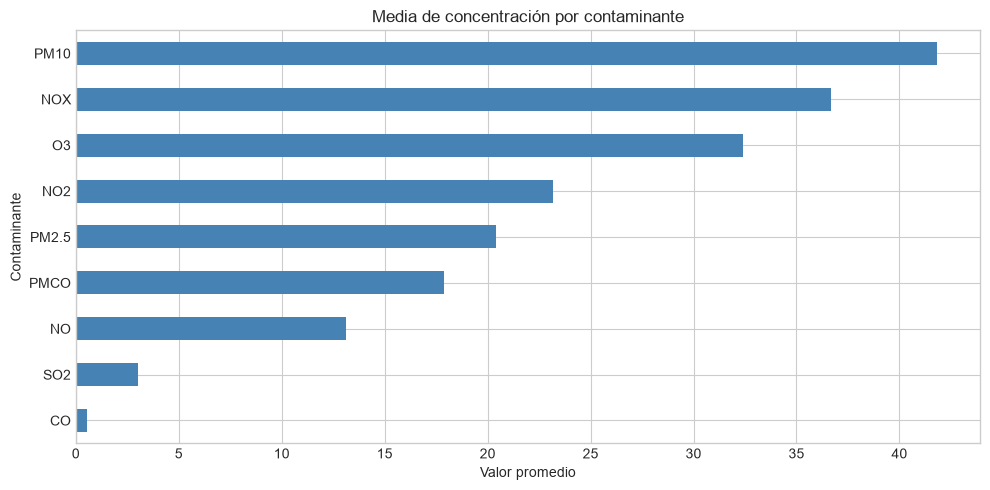

In [12]:
plt.figure(figsize=(10, 5))
central_tendency_by_parameter['media'].sort_values().plot(kind='barh', color='steelblue')
plt.title('Media de concentración por contaminante')
plt.xlabel('Valor promedio')
plt.ylabel('Contaminante')
plt.tight_layout()
plt.show()


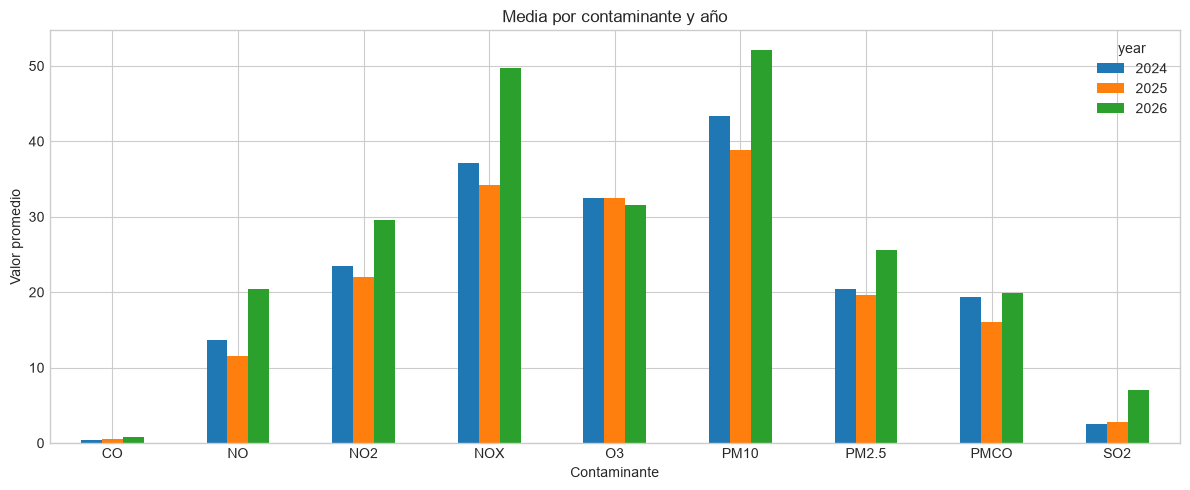

In [13]:
mean_by_year = central_tendency_by_year.pivot(
    index='id_parameter',
    columns='year',
    values='media'
)

mean_by_year.plot(kind='bar', figsize=(12, 5))
plt.title('Media por contaminante y año')
plt.xlabel('Contaminante')
plt.ylabel('Valor promedio')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


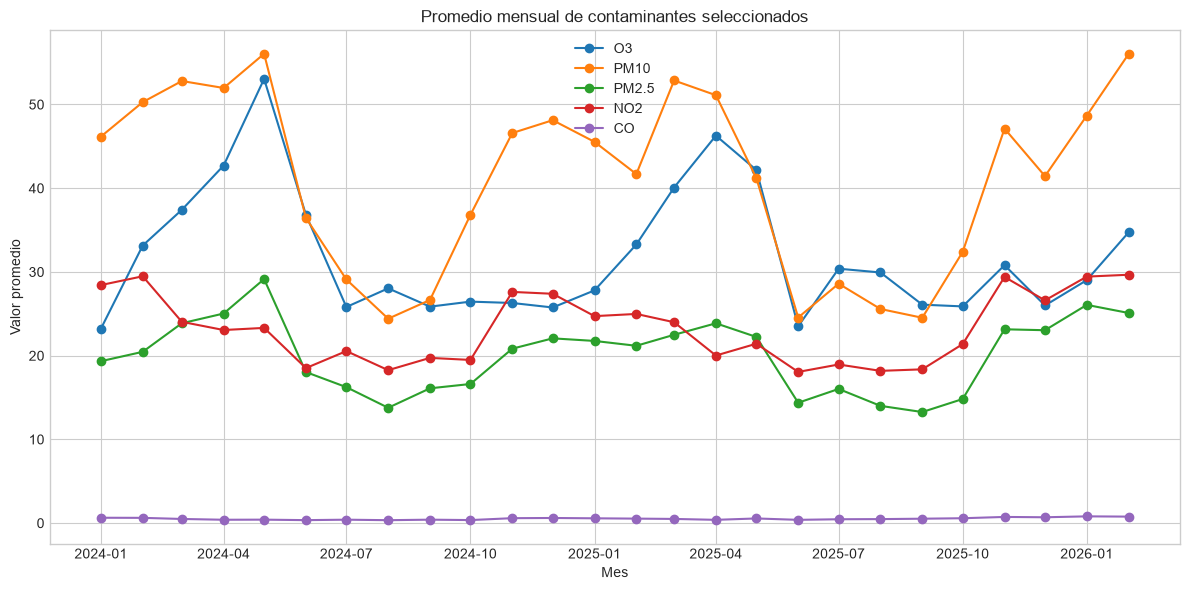

In [14]:
monthly_mean = (
    df_clean
    .groupby(['year', 'month', 'id_parameter'])['valor']
    .mean()
    .reset_index()
)

selected_parameters = ['O3', 'PM10', 'PM2.5', 'NO2', 'CO']
plot_data = monthly_mean[monthly_mean['id_parameter'].isin(selected_parameters)].copy()
plot_data['period'] = pd.to_datetime({
    'year': plot_data['year'].astype(int),
    'month': plot_data['month'].astype(int),
    'day': 1
})

plt.figure(figsize=(12, 6))
for parameter in selected_parameters:
    parameter_data = plot_data[plot_data['id_parameter'] == parameter]
    plt.plot(parameter_data['period'], parameter_data['valor'], marker='o', label=parameter)

plt.title('Promedio mensual de contaminantes seleccionados')
plt.xlabel('Mes')
plt.ylabel('Valor promedio')
plt.legend()
plt.tight_layout()
plt.show()


## 10. Observaciones iniciales

- La base final une información de 2024, 2025 y 2026.
- En 2026 solo hay datos hasta febrero en los archivos disponibles, por lo que no se debe comparar ese año como si estuviera completo.
- Las medidas de tendencia central se calculan sin valores nulos para evitar sesgos por datos no medidos.
- La media puede verse afectada por valores extremos; por eso conviene mirar también la mediana y la moda.
